In [1]:
import torch
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

# Search for root via .git
root = next(p for p in [Path().resolve(), *Path().resolve().parents] if (p / '.git').exists())

sys.path.insert(0, str(root / 'code'))
from sde_routines import *
from utils import *

sys.path.insert(0, str(root / 'data'))
from data_loader import *
from data_generator import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Get the data

In [2]:
n1 = int(1e7)

def energy(x):
    beta = .5
    return beta * x**4 - 5 * beta * x**2 - 0.5*beta * x

x1 = scalar_generator(n1,energy).cuda()

Normalizing constant Z ≈ 42.1725


/tmp/ipykernel_2958007/1599425869.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(x_space, np.exp(-energy(x_space))/np.exp(-energy(x_space)).sum()*1000/(x1.max()-x1.min()).cpu(), label='Analytical density')


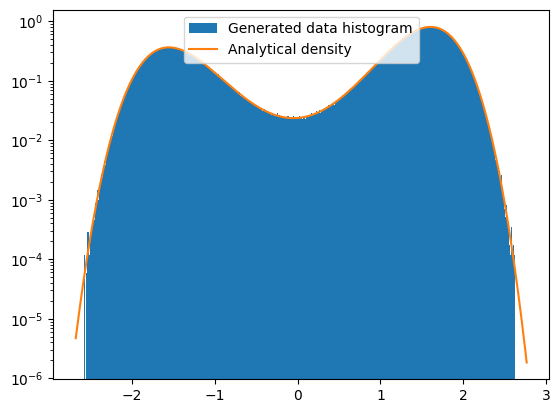

Estimated entropy: 1.0590675786211645 .


In [3]:
x_space = np.linspace(x1.min().cpu(), x1.max().cpu(), 1000)

plt.hist(x1.flatten().cpu(), density=True, bins='sqrt', label='Generated data histogram')
plt.plot(x_space, np.exp(-energy(x_space))/np.exp(-energy(x_space)).sum()*1000/(x1.max()-x1.min()).cpu(), label='Analytical density')

plt.yscale('log')
plt.legend(loc='best')

plt.show()

n_bins=2000
target_entropy = entropy(x1.flatten().cpu(), n_bins=n_bins, epsilon=0)
print('Estimated entropy:', target_entropy, '.')

### Choose the model

In [4]:
_, channels = x1.shape

# choose terms in the model
terms = ['x1', 'x2', 'x3', 'x4'] # ['x2', 'bimodal'] # ['x', 'x2', 'gaussian_mixture'] #'gaussian_mixture']# 'x_abs',

In [5]:
potentials = get_scalar_potentials(terms)

### Solve the SDE

In [6]:
# SDE parameters
interpolant = 'Cos'
nt          = 1000
t           = 1-(1-torch.linspace(0, 1, nt + 1))**1
sigma       = 1

nb_workers      = x1.shape[0] # number of particles
nb_interpolants = x1.shape[0] # number of I_t (not necessarily the dataset size, since several noise paths could be considered per data sample)

batch_size = x1.shape[0]

Solver = SDE(x1, nb_workers, nb_interpolants, t, sigma, potentials, batch_size, device=device, regularization=(0,0,0), interpolant=interpolant, x_0=None, x_k=None)

Signal detected as scalar: (B, C) = (10000000, 1).
The model has 4 potentials.


In [7]:
param_storage_frequency = 2

xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound = Solver(param_storage_frequency=param_storage_frequency)

1000it [01:16, 13.05it/s]


In [8]:
config = 'scalar_sigma_1'

save_results(xt, theta_t, dH_t_bound, t, root, config)

## Analyze the result

Looking at the sampled distribution and moment matching along the dynamics:

SDE interpolation complete!


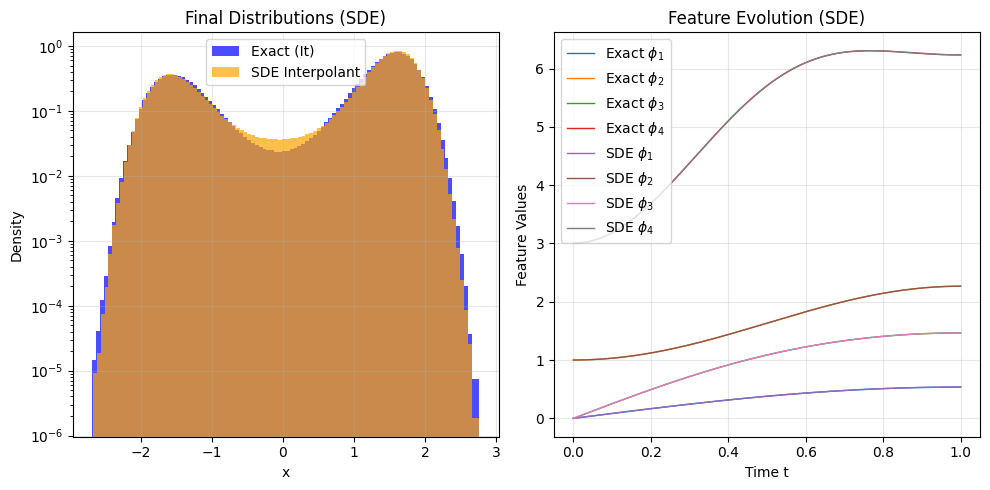


Final Results:
Final feature error: 0.000173
Max feature error during interpolation: 0.003582

Distribution Statistics:
Target (x1) - Mean: 0.5362, Std: 1.4068
Initial (x0) - Mean: -0.0000, Std: 1.0001
Final SDE interpolant - Mean: 0.5362, Std: 1.4068


In [9]:
t_param_storage = torch.cat([t[::param_storage_frequency], t[-1:]])

_ = plot_SD_results(Solver.x_0, x1, xt, barphi_e.cpu(), barphi_p.cpu(), t_param_storage, sigma, nt, potentials)

Entropy bound evolution and comparison with the equivalent gaussian entropy (covariance directly estimated from the original data):

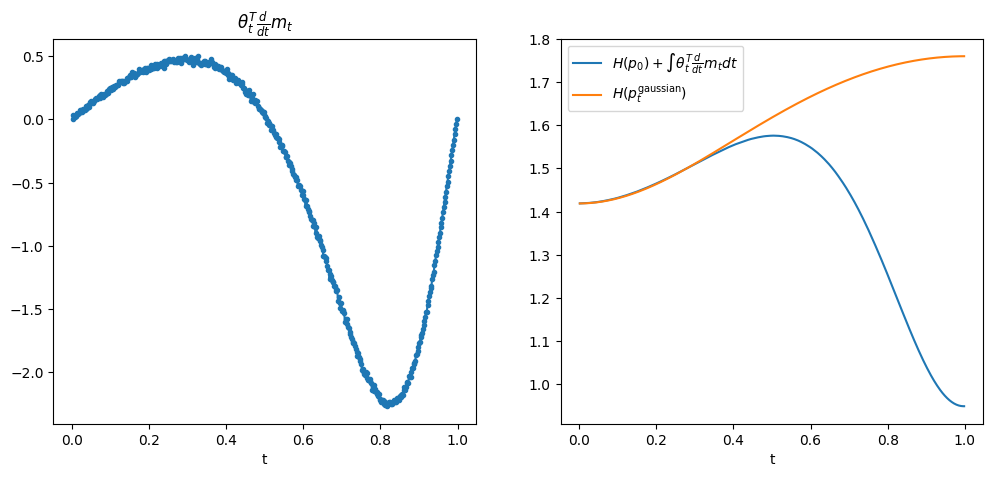

In [10]:
d = x1.shape[-1]
H_p_0 = (np.log(2*np.pi)+1)*d/2

H_t_bound = (dH_t_bound/nt*param_storage_frequency).cumsum(0).cpu() + H_p_0
H_t_gaussian = compute_gaussian_entropy(x1, interpolant, t_param_storage)

plot_entropy_bound_evolution(dH_t_bound, H_t_bound, H_t_gaussian[:-1], t_param_storage[:-1])

Parameters $\eta_t$ and $\theta_t$ evolution:

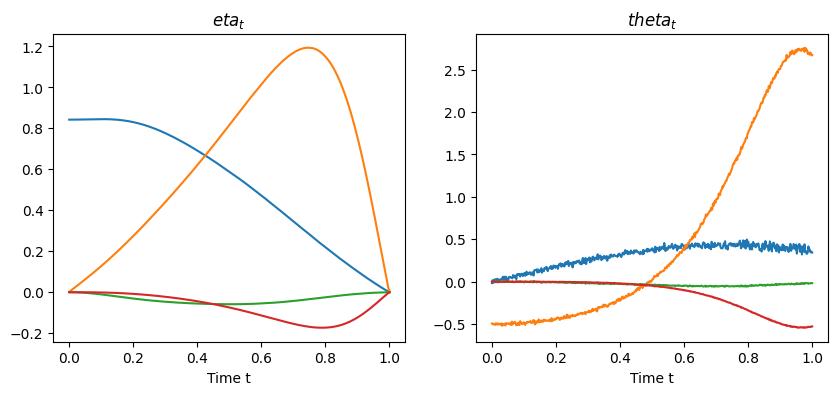

In [11]:
plt.figure(figsize=(10,4))

plt.subplot(121)
plt.plot(t_param_storage[:-1], eta_t.cpu())
plt.title('$eta_t$')
plt.xlabel('Time t')
plt.subplot(122)
plt.plot(t_param_storage[:-1], theta_t.cpu())
plt.title('$theta_t$')
plt.xlabel('Time t')

plt.xlabel('Time t')

plt.show()

In [12]:
beta = .5
print('Target theta:', str(torch.Tensor([beta/2, 5*beta, 0, -beta])))
print('Estimated averaged theta:', str(theta_t[-1].cpu()))

Target theta: tensor([ 0.2500,  2.5000,  0.0000, -0.5000])
Estimated averaged theta: tensor([ 0.3436,  2.6689, -0.0172, -0.5270])
